In [48]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns

df = pd.read_csv('../data/processed/candor_dataset_clean.csv')

# Linear Mixed Model
Unilateral model (actor enjoyment vs partner timing metrics) controls for:
* Some people are more positive in general
* Some calls are more positive in general

Mutual enjoyment model assumes:

* Each call is one independent unit

# Linear Mixed Model : one sided

A Mixed Model =  Fixed effects (normal regression effects) + Random effects (group level variation)

* Fixed effects: On average, across all conversations and speakers, how do partner behaviors (TFO, overlap, pauses, speech activity) affect actor enjoyment?
* Random effects: 
    - Each conversation (dyad) gets its own intercept because some conversations are naturally more enjoyable than others. Model estimates baseline_enjoyment + u_call (how much this convo differs from avg)
    - Each speaker also gets their own intercept. baseline_enjoyment + u_call + u_speaker (how much this speaker differs from avg)

Allows correct p-values and realistic modeling of dyadic data.

Some convos naturally fun and some ppl naturally fun. If no control - we may think partner tfo predicts enjoyment when it was just a fun convo

In [49]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "how_enjoyable_actor ~ tfo_partner + overlap_partner + pauses_partner + speech_activity_partner",
    data=df,
    groups=df["call_id"],          
    vc_formula={"Speaker": "0 + C(actor_id)"})
result = model.fit()
print(result.summary())

c:\Users\amb20\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


              Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: how_enjoyable_actor
No. Observations:  3200    Method:             REML               
No. Groups:        1600    Scale:              1.1552             
Min. group size:   2       Log-Likelihood:     -5881.8047         
Max. group size:   2       Converged:          Yes                
Mean group size:   2.0                                            
------------------------------------------------------------------
                        Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept                8.054    0.111 72.721 0.000  7.837  8.271
tfo_partner             -0.912    0.147 -6.218 0.000 -1.199 -0.624
overlap_partner         -0.307    0.768 -0.400 0.689 -1.812  1.198
pauses_partner          -0.662    0.271 -2.444 0.015 -1.193 -0.131
speech_activity_partner -0.575    0.155 -3.724 0.000 -0.878 -0.273
Speaker Va

* When partner TFO increases by 1 unit -> actor enjoyment decreases ~ 0.91 units
* No evidence that partner overlap predicts actor enjoyment.
* More pauses by the partner are associated with lower actor enjoyment.
* Higher partner speech activity -> lower actor enjoyment. (When no actor dominates - higher speech balance - higher enjoyment)

##  R**2
How much variance is explained by fixed effects only? (TFO, Overlap, Pauses, Speech Activity)

## Conditional R**2
How much variance is explained by fixed + random effects together? (partner behaviours and speaker differences)

In [50]:
print(result.cov_re)
print(result.vcomp)

Empty DataFrame
Columns: []
Index: []
[1.15515004]


In [51]:
var_residual = result.scale
var_random = result.vcomp[0]

# predictions 
fixed_preds = result.model.exog @ result.fe_params

# Variance of fixed effects
var_fixed = np.var(fixed_preds, ddof=1)

var_total = var_fixed + var_random + var_residual

r2_marginal = var_fixed / var_total
r2_conditional = (var_fixed + var_random) / var_total

print("Marginal R²:", r2_marginal)
print("Conditional R²:", r2_conditional)

Marginal R²: 0.020121336460907708
Conditional R²: 0.5100606682304539


* Only 2% of the variance in actor enjoyment is explained by partner behaviors (TFO, overlap, pauses, speech activity).
* 51% of the variance in actor enjoyment is explained when adding the random effects (speaker and dyad-level differences)

Predictors are statistically significant but effect size is small.

This demonstrates that the majority of the explained variance in conversational enjoyment is driven by individual idiosyncrasies and the specific dynamic of the dyad.


## Graphs

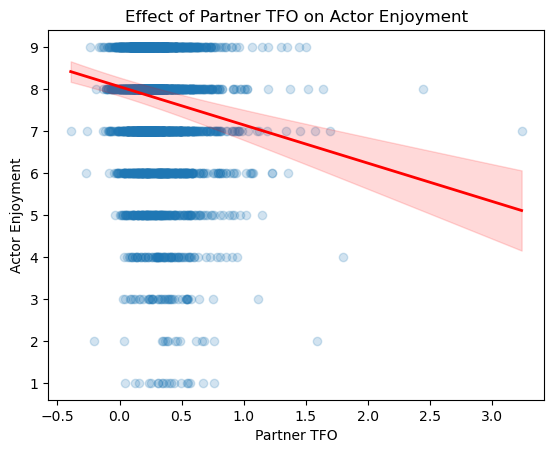

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Generate prediction line
x = np.linspace(df["tfo_partner"].min(), df["tfo_partner"].max(), 100)
y_pred = (
    result.params["Intercept"] +
    result.params["tfo_partner"] * x
)

alpha = 0.05
se_intercept = result.bse["Intercept"]
se_slope = result.bse["tfo_partner"]
z = stats.norm.ppf(1 - alpha/2)
ci_lower = y_pred - z * np.sqrt(se_intercept**2 + (x**2 * se_slope**2))
ci_upper = y_pred + z * np.sqrt(se_intercept**2 + (x**2 * se_slope**2))


plt.figure()
plt.scatter(df["tfo_partner"], df["how_enjoyable_actor"], alpha=0.2)
plt.plot(x, y_pred, linewidth=2, color = "red")
plt.fill_between(x, ci_lower, ci_upper, color="red", alpha=0.15)

plt.xlabel("Partner TFO")
plt.ylabel("Actor Enjoyment")
plt.title("Effect of Partner TFO on Actor Enjoyment")
plt.show()

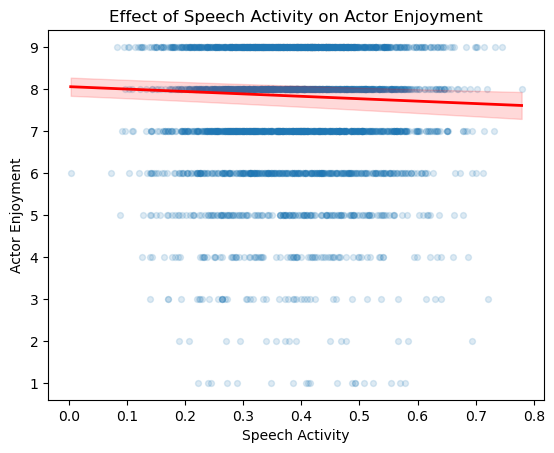

In [53]:
x = np.linspace(df["speech_activity_partner"].min(), df["speech_activity_partner"].max(), 100)
y_pred = (
    result.params["Intercept"] +
    result.params["speech_activity_partner"] * x
)

alpha = 0.05
se_intercept = result.bse["Intercept"]
se_slope = result.bse["speech_activity_partner"]
z = stats.norm.ppf(1 - alpha/2)
ci_lower = y_pred - z * np.sqrt(se_intercept**2 + (x**2 * se_slope**2))
ci_upper = y_pred + z * np.sqrt(se_intercept**2 + (x**2 * se_slope**2))

plt.figure()
plt.scatter(df["speech_activity_partner"], df["how_enjoyable_actor"], s=18, alpha=0.15)
plt.plot(x, y_pred, linewidth=2, color = "red")

plt.fill_between(x, ci_lower, ci_upper, color="red", alpha=0.15)
plt.xlabel("Speech Activity")
plt.ylabel("Actor Enjoyment")
plt.title("Effect of Speech Activity on Actor Enjoyment")
plt.show()

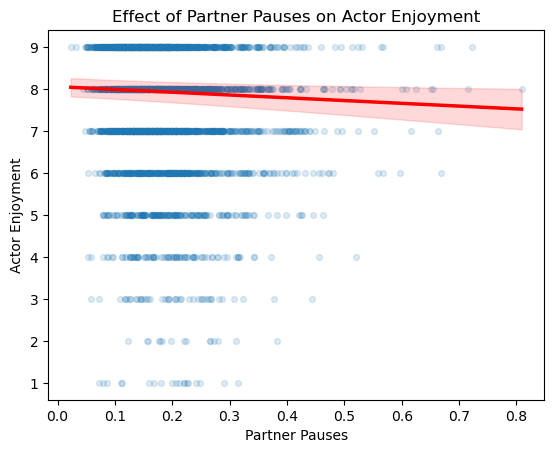

In [54]:
x = np.linspace(df["pauses_partner"].min(), df["pauses_partner"].max(), 100)
y_pred = (
    result.params["Intercept"] +
    result.params["pauses_partner"] * x
)

alpha = 0.05
se_intercept = result.bse["Intercept"]
se_slope = result.bse["pauses_partner"]
z = stats.norm.ppf(1 - alpha/2)
ci_lower = y_pred - z * np.sqrt(se_intercept**2 + (x**2 * se_slope**2))
ci_upper = y_pred + z * np.sqrt(se_intercept**2 + (x**2 * se_slope**2))

plt.figure()
plt.scatter(df["pauses_partner"], df["how_enjoyable_actor"], s=18, alpha=0.15)
plt.plot(x, y_pred, linewidth=2.5, color = "red")

plt.fill_between(x, ci_lower, ci_upper, color="red", alpha=0.15)
plt.xlabel("Partner Pauses")
plt.ylabel("Actor Enjoyment")
plt.title("Effect of Partner Pauses on Actor Enjoyment")
plt.show()

C:\Users\amb20\AppData\Local\Temp\ipykernel_19644\1704405164.py:19: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(


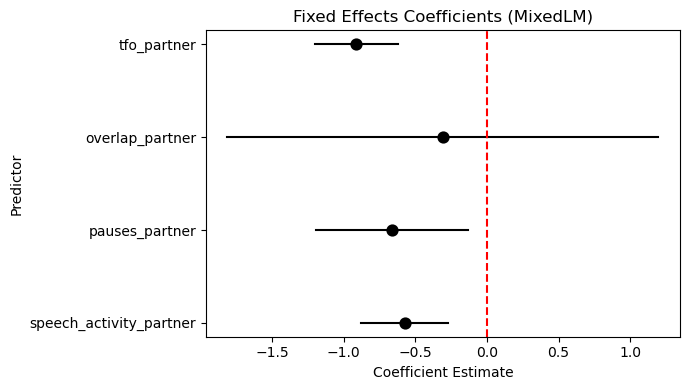

In [55]:
coefs = result.params
conf = result.conf_int()
conf.columns = ['lower', 'upper']

# Keep only fixed effects (exclude random effects)
fixed = coefs.index[coefs.index.str.contains('tfo') |
                    coefs.index.str.contains('overlap') |
                    coefs.index.str.contains('pauses') |
                    coefs.index.str.contains('speech')]

df_plot = pd.DataFrame({
    'coef': coefs[fixed],
    'lower': conf.loc[fixed, 'lower'],
    'upper': conf.loc[fixed, 'upper']
})


plt.figure(figsize=(7, 4))
sns.pointplot(
    x='coef', 
    y=df_plot.index, 
    data=df_plot, 
    join=False, 
    color='black'
)

# Add CI lines
for i, row in df_plot.iterrows():
    plt.plot([row['lower'], row['upper']], [i, i], color='black')

plt.axvline(0, color='red', linestyle='--')
plt.title("Fixed Effects Coefficients (MixedLM)")
plt.xlabel("Coefficient Estimate")
plt.ylabel("Predictor")
plt.tight_layout()
plt.show()
